## Import libraries and data loader

In [72]:
import pandas as pd 
import numpy as np

In [73]:
obis_data = pd.read_csv('../dataset/gbif/thunnus_albacares_gbif.csv')

In [74]:
print(obis_data.columns.tolist())

['key', 'datasetKey', 'publishingOrgKey', 'installationKey', 'hostingOrganizationKey', 'publishingCountry', 'protocol', 'lastCrawled', 'lastParsed', 'crawlId', 'extensions', 'basisOfRecord', 'occurrenceStatus', 'classifications', 'taxonKey', 'kingdomKey', 'phylumKey', 'orderKey', 'familyKey', 'genusKey', 'speciesKey', 'acceptedTaxonKey', 'scientificName', 'scientificNameAuthorship', 'acceptedScientificName', 'kingdom', 'phylum', 'order', 'family', 'genus', 'species', 'genericName', 'specificEpithet', 'taxonRank', 'taxonomicStatus', 'iucnRedListCategory', 'dateIdentified', 'decimalLatitude', 'decimalLongitude', 'coordinateUncertaintyInMeters', 'gadm', 'year', 'month', 'day', 'eventDate', 'startDayOfYear', 'endDayOfYear', 'issues', 'modified', 'lastInterpreted', 'references', 'license', 'isSequenced', 'identifiers', 'media', 'facts', 'relations', 'isInCluster', 'datasetName', 'recordedBy', 'identifiedBy', 'dnaSequenceID', 'geodeticDatum', 'countryCode', 'recordedByIDs', 'identifiedByIDs'

In [75]:
# filter columns
filtered_columns = ['scientificName',
                    'individualCount', # The number of individuals represented at the time of occurrence
                    'organismQuantity', # The number or enumeration value for the quantity of organisms
                    'organismQuantityType', # The type of quantity of organisms (e.g., mass, volume, etc.)
                    'sex', # the sex of the biological individual(s) represented in the occurrence
                    'lifeStage', # The life stage or developmental stage of the biological individual(s) represented in the occurrence
                    'occurrenceStatus', # Present for yes, absent for no, mostly present

                    ### Locations
                    'continent',
                    'countryCode',
                    'stateProvince',
                    'island',
                    'decimalLatitude',
                    'decimalLongitude',
                    'elevation',
                    'elevationAccuracy',

                    ## Date
                    'eventDate',
                    'year',
                    'month',
                    'day'
]
obis_data_subset = obis_data[filtered_columns]

In [76]:
print(obis_data_subset.head(5))

                         scientificName  individualCount  organismQuantity  \
0  Thunnus albacares (Bonnaterre, 1788)              NaN               NaN   
1  Thunnus albacares (Bonnaterre, 1788)              NaN               NaN   
2  Thunnus albacares (Bonnaterre, 1788)              NaN               NaN   
3  Thunnus albacares (Bonnaterre, 1788)              NaN               NaN   
4  Thunnus albacares (Bonnaterre, 1788)              NaN               NaN   

  organismQuantityType  sex lifeStage occurrenceStatus      continent  \
0                  NaN  NaN       NaN          PRESENT            NaN   
1                  NaN  NaN       NaN          PRESENT            NaN   
2                  NaN  NaN       NaN          PRESENT           ASIA   
3                  NaN  NaN       NaN          PRESENT  NORTH_AMERICA   
4                  NaN  NaN       NaN          PRESENT  NORTH_AMERICA   

  countryCode stateProvince island  decimalLatitude  decimalLongitude  \
0          CR      

In [77]:
print(obis_data_subset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   scientificName        300 non-null    object 
 1   individualCount       58 non-null     float64
 2   organismQuantity      18 non-null     float64
 3   organismQuantityType  18 non-null     object 
 4   sex                   11 non-null     object 
 5   lifeStage             17 non-null     object 
 6   occurrenceStatus      300 non-null    object 
 7   continent             146 non-null    object 
 8   countryCode           296 non-null    object 
 9   stateProvince         153 non-null    object 
 10  island                23 non-null     object 
 11  decimalLatitude       300 non-null    float64
 12  decimalLongitude      300 non-null    float64
 13  elevation             2 non-null      float64
 14  elevationAccuracy     2 non-null      float64
 15  eventDate             3

In [78]:
print(obis_data_subset.describe())

       individualCount  organismQuantity  decimalLatitude  decimalLongitude  \
count        58.000000         18.000000       300.000000        300.000000   
mean        200.344828        122.833333         9.996353        -34.527977   
std        1311.679057        117.759226        19.922180         91.350041   
min           1.000000         15.000000       -37.521668       -160.060070   
25%           1.000000         32.625000         1.601566        -91.821306   
50%           2.000000        106.500000        10.674413        -77.658020   
75%          10.000000        173.500000        26.149987         41.281148   
max       10000.000000        500.000000        41.323872        178.775938   

       elevation  elevationAccuracy         year       month         day  
count        2.0                2.0   300.000000  297.000000  296.000000  
mean       150.0              150.0  2023.566667    6.474747   16.016892  
std          0.0                0.0     1.084501    3.271530   

In [79]:
# Unique value of categorical columns
categorical_columns = ['scientificName', 'organismQuantityType', 'sex', 'lifeStage', 'occurrenceStatus', 'continent', 'countryCode', 'stateProvince', 'island']
for col in categorical_columns:
    unique_values = obis_data_subset[col].unique()
    print(f"Unique values in column '{col}': {unique_values}")

Unique values in column 'scientificName': ['Thunnus albacares (Bonnaterre, 1788)']
Unique values in column 'organismQuantityType': [nan 'número-de-indivíduos' 'Peso en kg']
Unique values in column 'sex': [nan 'Indeterminate']
Unique values in column 'lifeStage': [nan 'Juvenile' 'Adult' 'Unknown' 'Larva']
Unique values in column 'occurrenceStatus': ['PRESENT']
Unique values in column 'continent': [nan 'ASIA' 'NORTH_AMERICA' 'OCEANIA' 'SOUTH_AMERICA' 'AFRICA' 'EUROPE']
Unique values in column 'countryCode': ['CR' 'NZ' 'OM' 'PA' 'US' nan 'MV' 'BQ' 'IN' 'LK' 'MX' 'MZ' 'CO' 'EC' 'AU'
 'JP' 'PG' 'CV' 'SC' 'CL' 'ID' 'PF' 'FJ' 'ES' 'BM' 'TW' 'MY' 'KM' 'SV'
 'CK' 'MG' 'YE' 'GT' 'PH' 'YT' 'PT' 'CU' 'BR' 'MH' 'TZ' 'EG' 'CW' 'ZA'
 'CN' 'BZ' 'SN' 'MP' 'SR']
Unique values in column 'stateProvince': [nan 'Muscat' 'Veraguas' 'New York' 'Hawaii' 'Texas' 'Bay of Plenty'
 'Bonaire' 'Puducherry' 'Gampaha' 'Colima' 'Galápagos' 'Okinawa' 'Galle'
 'Sal' 'Valparaíso' 'Sulawesi Tengah' 'Îles Sous-le-Vent'
 'Sa

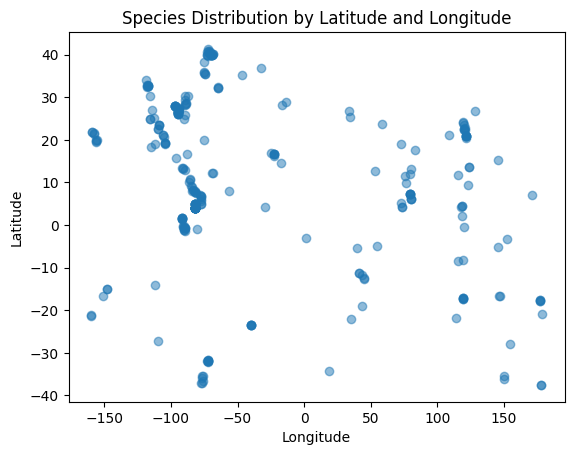

In [80]:
# distribution by lat long
import matplotlib.pyplot as plt
plt.scatter(obis_data_subset['decimalLongitude'], obis_data_subset['decimalLatitude'], alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Species Distribution by Latitude and Longitude')
plt.show()

# Join with environmental information